# INR Features — PCA Visualisation & Segmentation

Mirrors `metaseg_3d_inference.py` exactly:
- Affine-based world coordinates (not linspace)
- Percentile normalization on non-zero voxels (0.5 – 99.5)
- Meta-learned INR init → fit → extract penultimate features
- Classifier inference → segmentation map
- PCA of features (first 5 PCs per orthogonal slice)

In [10]:
import os
import os.path as osp
import sys
from copy import deepcopy

import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

sys.path.insert(0, osp.abspath("."))  # repo root
from modules import models

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
torch.manual_seed(422)

In [ ]:
# ── Configuration (matches metaseg_3d_inference.py) ───────────────────────────
WEIGHTS_FILE = "/scratch/thesis-saverio/dumps/metaseg_3d_step1-normalized-robust/weights3d_num_classes_4_IS_2.pth"
CLASSIFIER_WEIGHTS_FILE = "/scratch/thesis-saverio/dumps/weights_3d/classifierfinal_weights_LR_5e-05_exp_gamma_3.0_INR_300it_skip_pixels_2_subset200.pth"

# Input NIfTI — change this
# INPUT_IMAGE = "/home/savpr/thesis/Fit-Pixels-Get-Surfaces/test-7/t1w.nii.gz"
# INPUT_IMAGE = "/home/savpr/thesis/Fit-Pixels-Get-Surfaces/test-6/sub-171-t1w.nii.gz"
INPUT_IMAGE = "/home/savpr/thesis/Fit-Pixels-Get-Surfaces/test-8/subject-0001-ABAIDE.nii.gz"

TEST_RUN_STEPS  = 300
SKIP_PIXELS     = 2
NUM_CLASSES     = 4
NUM_CLASSES_AND_ONE = NUM_CLASSES + 1
NORMALIZE_FEATURES  = False

inr_config = {
    "in_features": 3,
    "out_features": 1,
    "hidden_features": 256,
    "hidden_layers": 4,
}
segmentation_config = {
    "hidden_features": [256],
    "output_features": NUM_CLASSES_AND_ONE,
}

In [12]:
# ── Coordinate helper (identical to inference script) ─────────────────────────
def get_coords_from_affine(h: int, w: int, d: int, affine: np.ndarray) -> torch.Tensor:
    ii = torch.arange(h, dtype=torch.float32)
    jj = torch.arange(w, dtype=torch.float32)
    kk = torch.arange(d, dtype=torch.float32)
    grid_i, grid_j, grid_k = torch.meshgrid(ii, jj, kk, indexing="ij")
    ones = torch.ones_like(grid_i)
    voxel_coords = torch.stack([grid_i, grid_j, grid_k, ones], dim=-1)
    affine_t = torch.from_numpy(affine).float()
    world_coords = voxel_coords @ affine_t.T
    return world_coords[..., :3]

In [13]:
# ── Load models ───────────────────────────────────────────────────────────────
inr_seg_model = (
    models.SirenSegINR(
        inr_type="siren",
        inr_config=inr_config,
        segmentation_config=segmentation_config,
        normalize_features=NORMALIZE_FEATURES,
    )
    .float()
    .cuda()
)

print(f"Loading meta-learned weights from: {WEIGHTS_FILE}")
weights_from_metalearning = torch.load(WEIGHTS_FILE)
best_inr_weights = weights_from_metalearning["best_inr_weights"]

classifier_model = deepcopy(inr_seg_model.segmentation_head)
if osp.isfile(CLASSIFIER_WEIGHTS_FILE):
    print(f"Loading classifier weights from: {CLASSIFIER_WEIGHTS_FILE}")
    classifier_weights = torch.load(CLASSIFIER_WEIGHTS_FILE)
    try:
        classifier_model.load_state_dict(classifier_weights["final_clf_weights"])
    except KeyError:
        classifier_weights_fixed = {
            k.replace("segmentation_head.segmentation_head", "segmentation_head"): v
            for k, v in classifier_weights.items()
        }
        classifier_model.load_state_dict(classifier_weights_fixed)
else:
    print("Classifier weights file not found — using best_classifier_weights from Step 1 checkpoint")
    best_clf_weights = weights_from_metalearning["best_classifier_weights"]
    best_clf_weights_fixed = {
        k.replace("segmentation_head.segmentation_head", "segmentation_head"): v
        for k, v in best_clf_weights.items()
    }
    classifier_model.load_state_dict(best_clf_weights_fixed)
classifier_model.eval()
print("Models ready.")

INR(
  (loss_function): MSELoss()
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=3, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (5): Linear(in_features=256, out_features=1, bias=True)
  )
)
SegmentationModel(
  (segmentation_head): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=5, bias=True)
  )
)
Loading meta-learned weights from: /scratch/thesis-saverio/dumps/metaseg_3d_step1-normalized-robust/weights3d_num_classes_4_IS_2.pth
Loading classifier weights from: /scratch/thesis-sa

In [14]:
# ── Load & preprocess NIfTI (mirrors inference script exactly) ────────────────
img_nib = nib.load(INPUT_IMAGE)
img_data = img_nib.get_fdata().astype(np.float32)
affine = img_nib.affine
original_shape = img_data.shape
print(f"Shape: {original_shape}")

# Percentile normalization on non-zero voxels
img_data = np.nan_to_num(img_data, nan=0.0, posinf=0.0, neginf=0.0)
support_mask = img_data != 0
if support_mask.sum() == 0:
    img_data = np.zeros_like(img_data)
else:
    vals = img_data[support_mask]
    low, high = np.percentile(vals, 0.5), np.percentile(vals, 99.5)
    if high - low < 1e-8:
        img_data = np.zeros_like(img_data)
    else:
        img_data = np.clip(img_data, low, high)
        img_data = (img_data - low) / (high - low)
        img_data[~support_mask] = 0.0

# Affine-based world coordinates, normalized to [-1, 1]
h, w, d = img_data.shape
coords_mtx = get_coords_from_affine(h, w, d, affine)
flat = coords_mtx.reshape(-1, 3)
c_min = flat.min(dim=0).values
c_max = flat.max(dim=0).values
coords_mtx = 2.0 * (coords_mtx - c_min) / (c_max - c_min) - 1.0

# Subsampled tensors for INR fitting
img_sub = img_data[::SKIP_PIXELS, ::SKIP_PIXELS, ::SKIP_PIXELS]
coords_sub = coords_mtx[::SKIP_PIXELS, ::SKIP_PIXELS, ::SKIP_PIXELS]
img_tensor        = torch.from_numpy(img_sub.reshape(-1, 1)).float().cuda()[None]
coords_sub_tensor = coords_sub.reshape(-1, 3).float().cuda()[None]

# Full-resolution coords for classifier
coords_full_tensor = coords_mtx.reshape(-1, 3).float().cuda()[None]

print(f"img_tensor:         {img_tensor.shape}")
print(f"coords_sub_tensor:  {coords_sub_tensor.shape}")
print(f"coords_full_tensor: {coords_full_tensor.shape}")

Shape: (182, 218, 182)
img_tensor:         torch.Size([1, 902629, 1])
coords_sub_tensor:  torch.Size([1, 902629, 3])
coords_full_tensor: torch.Size([1, 7221032, 3])


In [15]:
# ── Fit INR & extract features ────────────────────────────────────────────────
inr_model = models.INR(**inr_config).float().cuda()
inr_model.load_state_dict(
    {k.replace("inr.", ""): v.clone().detach() for k, v in deepcopy(best_inr_weights).items()}
)
inr_model.compile()

print(f"Fitting INR ({TEST_RUN_STEPS} steps on subsampled coords)...")
inr_model.fit(coords_sub_tensor, img_tensor, epochs=TEST_RUN_STEPS, disable_tqdm=False)

print("Extracting features at full resolution...")
with torch.no_grad():
    _, img_features = inr_model.forward_w_features(coords_full_tensor)
    features_flat = img_features[-2].squeeze(0).cpu().numpy()  # (N, 256)

print(f"Features shape: {features_flat.shape}")

Fitting INR (300 steps on subsampled coords)...


Epoch: 299/300. Loss: 0.000962 : 100%|██████████| 300/300 [00:23<00:00, 12.56it/s]


Extracting features at full resolution...
Features shape: (7221032, 256)


In [16]:
# ── Run classifier → segmentation map ─────────────────────────────────────────
with torch.no_grad():
    clf_input = torch.from_numpy(features_flat).float().cuda()
    if NORMALIZE_FEATURES:
        clf_input = nn.functional.normalize(clf_input, dim=-1)
    output = classifier_model(clf_input)
    pred_probs   = nn.functional.softmax(output.unsqueeze(0).unsqueeze(0), dim=-1)
    predictions  = pred_probs.argmax(dim=-1).reshape(original_shape)

seg_map = predictions.detach().cpu().numpy().astype(np.uint8)
print(f"Segmentation shape: {seg_map.shape}")
print(f"Unique classes:     {np.unique(seg_map)}")

del inr_model
torch.cuda.empty_cache()

Segmentation shape: (182, 218, 182)
Unique classes:     [0 1 2 3 4]


In [17]:
# ── PCA on full-resolution features ───────────────────────────────────────────
pca = PCA(n_components=5, random_state=0)
pca.fit(features_flat)
ev = pca.explained_variance_ratio_ * 100
print(f"PC1={ev[0]:.1f}%  PC2={ev[1]:.1f}%  PC3={ev[2]:.1f}%  PC4={ev[3]:.1f}%  PC5={ev[4]:.1f}%  (total {ev.sum():.1f}%)")

PC1=22.4%  PC2=9.0%  PC3=5.9%  PC4=2.1%  PC5=2.0%  (total 41.4%)


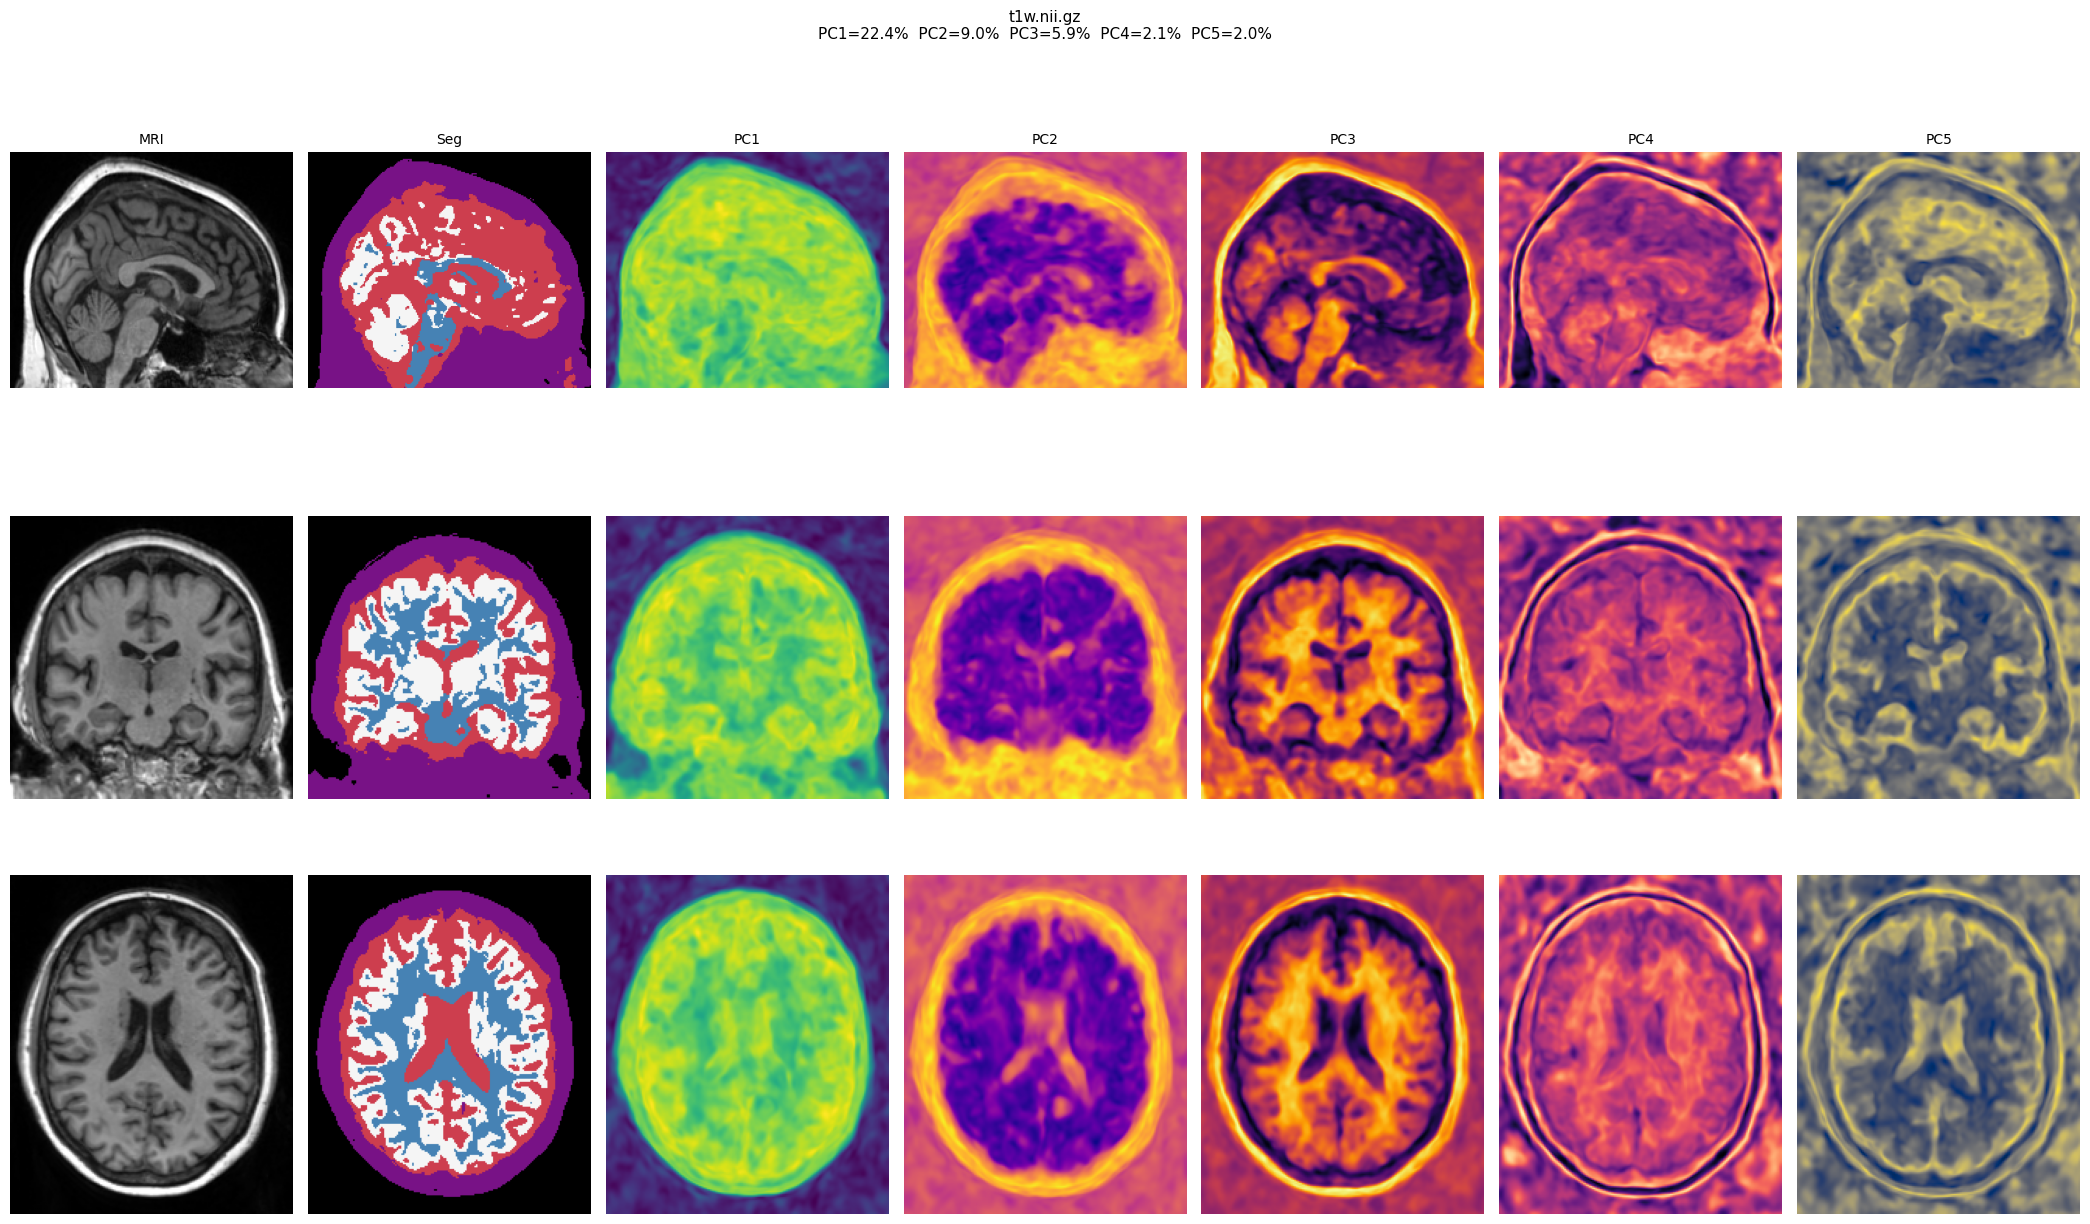

In [18]:
# ── Visualise: middle slice per orthogonal view ────────────────────────────────
# Colors taken directly from FreeSurferColorLUT.txt by label index
CLASS_COLORS = {
    0: [  0,   0,   0],  # 0  Unknown
    1: [ 70, 130, 180],  # 1  Left-Cerebral-Exterior
    2: [245, 245, 245],  # 2  Left-Cerebral-White-Matter
    3: [205,  62,  78],  # 3  Left-Cerebral-Cortex
    4: [120,  18, 134],  # 4  Left-Lateral-Ventricle
}

def seg_to_rgb(seg_slice):
    rgb = np.zeros((*seg_slice.shape, 3), dtype=np.uint8)
    for cls, color in CLASS_COLORS.items():
        rgb[seg_slice == cls] = color
    return rgb

def to_pc_images(feats_2d):
    proj = pca.transform(feats_2d)  # (N, 5)
    imgs = []
    for i in range(5):
        lo, hi = proj[:, i].min(), proj[:, i].max()
        norm = ((proj[:, i] - lo) / (hi - lo + 1e-8)).astype(np.float32)
        imgs.append(norm)
    return imgs

features_vol = features_flat.reshape(*original_shape, -1)  # (H, W, D, 256)

COLORMAPS = ["viridis", "plasma", "inferno", "magma", "cividis"]
views = {
    "Sagittal (x)": (0, original_shape[0] // 2),
    "Coronal  (y)": (1, original_shape[1] // 2),
    "Axial    (z)": (2, original_shape[2] // 2),
}

fig, axes = plt.subplots(3, 7, figsize=(21, 13))
fig.suptitle(
    f"{osp.basename(INPUT_IMAGE)}\n"
    f"PC1={ev[0]:.1f}%  PC2={ev[1]:.1f}%  PC3={ev[2]:.1f}%  PC4={ev[3]:.1f}%  PC5={ev[4]:.1f}%",
    fontsize=11,
)
col_titles = ["MRI", "Seg", "PC1", "PC2", "PC3", "PC4", "PC5"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

for row, (label, (axis, idx)) in enumerate(views.items()):
    feat_s = np.take(features_vol, idx, axis=axis)    # (a, b, 256)
    img_s  = np.take(img_data,    idx, axis=axis).T
    seg_s  = np.take(seg_map,     idx, axis=axis).T

    a, b, _ = feat_s.shape
    pc_imgs = [p.reshape(a, b).T for p in to_pc_images(feat_s.reshape(-1, 256))]

    axes[row, 0].imshow(img_s,          cmap="gray",    origin="lower")
    axes[row, 1].imshow(seg_to_rgb(seg_s),              origin="lower")
    for col, (pc_img, cmap) in enumerate(zip(pc_imgs, COLORMAPS), start=2):
        axes[row, col].imshow(pc_img, cmap=cmap, origin="lower")

    axes[row, 0].set_ylabel(label, fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()